# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Datasets loading

In [29]:
url1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df1 = pd.read_csv(url1) #training models

- HUFL, HULL: High-usage frequency limits (upper/lower)
- MUFL, MULL: Medium-usage frequency limits (upper/lower)
- LUFL, LULL:
- OT: Operational Temperature (target variable)

# Analyse du jeu de donnée ETTH1

In [30]:
df1.drop(columns=["HUFL","HULL"], inplace=True)
df1['date'] = pd.to_datetime(df1['date'])
df1.set_index('date', inplace=True)

In [31]:
# from statsmodels.tsa.seasonal import STL

# decomposition = STL(df1['OT_1'], period=24, seasonal=17).fit()
# decomposition.plot()
# plt.show()
# trend = decomposition.trend

# df = pd.DataFrame(trend.dropna().values, columns=['trend'])
# df.index = trend.dropna().index
# df['lag1'] = df['trend'].shift(1)  # Previous 1-hour data
# df['lag2'] = df['trend'].shift(2)  # Previous 2-hour data
# df['lag3'] = df['trend'].shift(3)  # Previous 3-hour data 
# df

## Univariate

- need to scale the data
- 

Pour du multivarier (TARGET + 1 COVARIABLE), voici à quoi pourrait ressembler le train ::
- X : [[[Y-w, X-W], ..., [Y-2, X-2], [Y-1, X-1]]] 
- y : [[Y]]

In [32]:
WINDOW = 168
HORIZON = 1
TARGET = "OT"
EPOCHS = 50
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()-2 if os.cpu_count() > 4 else 1
NB_OF_FEATURES = 1
HIDDEN_SIZE_LAYER = 32
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [33]:
def create_sequences(data):
    input, output = [], []
    if isinstance(data, pd.DataFrame):
        for idx in range(0, len(data) - WINDOW - HORIZON + 1):
            input.append(data[TARGET][idx:idx + WINDOW]) # de t à t+w
            output.append(data[TARGET].iloc[idx + WINDOW:idx + WINDOW + HORIZON]) # de t+w à t+w+h

    elif isinstance(data, np.ndarray):
        for idx in range(0, len(data) - WINDOW - HORIZON + 1):
            input.append(data[idx:idx + WINDOW, 0])
            output.append(data[idx + WINDOW:idx + WINDOW + HORIZON, 0])
    return np.asarray(input), np.asarray(output)

In [34]:
def splitting(X, y, n_test):
    X  = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    X_train, X_val, X_test = X[:-2*n_test], X[-2*n_test:-n_test], X[-n_test:]
    y_train, y_val, y_test = y[:-2*n_test], y[-2*n_test:-n_test], y[-n_test:]

    assert len(X_train)+len(X_test)+len(X_val) == len(X)
    assert len(y_train)+len(y_val)+len(y_test) == len(y)
    print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [35]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i]
    

def get_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test):
    train_dataset = CustomDataset(X_train, y_train)
    val_dataset = CustomDataset(X_val, y_val)
    test_dataset = CustomDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, pin_memory=True, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True if NUM_WORKERS > 0 else False)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True if NUM_WORKERS > 0 else False)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True if NUM_WORKERS > 0 else False)

    for input ,output in train_loader:
        x_batch , y_batch = input.to(device), output.to(device)
        print("For TRAIN :", x_batch.shape, y_batch.shape)
        break
    for input ,output in test_loader:
        x_batch , y_batch = input.to(device), output.to(device)
        print("For TEST :", x_batch.shape, y_batch.shape)
        break

    return train_loader, val_loader, test_loader

In [36]:
univariate1 = pd.DataFrame(df1[TARGET].copy())

scaler = MinMaxScaler(feature_range=(-1,1))
scaled_data = scaler.fit_transform(univariate1)
X, y = create_sequences(scaled_data)
X = X.reshape(X.shape[0], X.shape[1], 1) # reshape for LSTM input : (n,WINDOW) --> (n,WINDOW,1)

In [38]:
X.shape,y.shape

((17252, 168, 1), (17252, 1))

### Torch

In [39]:
X_train, X_val, X_test, y_train, y_val, y_test = splitting(X,y,2880)
print("On a bien des séquences [lag-w, ..., lag-1], ce qui est le bon sens pour le LSTM.") if y_train[0] == X_train[1][WINDOW-1] else print("Les séquences sont à l'envers, c'est à dire [lag-1, ..., lag-w]")
train_loader, val_loader, test_loader = get_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test)

torch.Size([11492, 168, 1]) torch.Size([2880, 168, 1]) torch.Size([2880, 168, 1]) torch.Size([11492, 1]) torch.Size([2880, 1]) torch.Size([2880, 1])
On a bien des séquences [lag-w, ..., lag-1], ce qui est le bon sens pour le LSTM.
For TRAIN : torch.Size([64, 168, 1]) torch.Size([64, 1])
For TEST : torch.Size([64, 168, 1]) torch.Size([64, 1])


In [40]:
import sys
import os

# On récupère le chemin du dossier "src"
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from utils.log_checkpoint import *
import pathlib

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layer, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layer = num_stacked_layer

        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layer, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layer, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layer, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0,c0))
        out = self.fc(out[:, -1, :])
        return out
    
model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1, output_size=HORIZON).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
loss  = nn.MSELoss()

logname = "LSTM"
logdir = generate_unique_logpath("outputs/checkpoints", logname)
setup_logging(logdir, mode="train")
logdir = pathlib.Path(logdir)
checkpoint = ModelCheckpoint(model, str(logdir / "best_model.pt"), min_is_best=True)

In [41]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    epoch_loss = 0
    num_samples = 0

    for inputs, targets in tqdm.tqdm(loader, leave=False):
        inputs  = inputs.to(device,non_blocking=True) #non_blocking : accelère les transferts CPU->GPU
        targets = targets.to(device,non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * inputs.size(0)
        num_samples += targets.size(0)
    epoch_loss = epoch_loss / num_samples
    return epoch_loss


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()

    epoch_loss = 0.0
    num_samples = 0

    for inputs, targets in tqdm.tqdm(loader, leave=False):
        inputs = inputs.to(device,non_blocking=True)
        targets = targets.to(device,non_blocking=True)

        logits = model(inputs)
        loss = criterion(logits, targets)

        epoch_loss += loss.item() * inputs.size(0)
        num_samples += targets.size(0)
    epoch_loss = epoch_loss / num_samples
    return epoch_loss

for epoch in tqdm.tqdm(range(EPOCHS)):
    train_loss = train_one_epoch(model, train_loader, loss, optim, device)
    val_loss = validate(model, val_loader, loss, device)
    print(f"Epoch {epoch+1},\tTrain Loss : {train_loss:.5f},\tVal Loss : {val_loss:.5f}")
    
    updated = checkpoint.update(val_loss)
    if updated:
        print("New best model saved!")

  2%|▏         | 1/50 [00:00<00:45,  1.07it/s]

Epoch 1,	Train Loss : 0.03331,	Val Loss : 0.00343
New best model saved!


  4%|▍         | 2/50 [00:01<00:33,  1.44it/s]

Epoch 2,	Train Loss : 0.00466,	Val Loss : 0.00145
New best model saved!


  6%|▌         | 3/50 [00:01<00:28,  1.66it/s]

...

Epoch 48,	Train Loss : 0.00155,	Val Loss : 0.00063


 98%|█████████▊| 49/50 [00:25<00:00,  2.03it/s]

Epoch 49,	Train Loss : 0.00155,	Val Loss : 0.00053
New best model saved!


100%|██████████| 50/50 [00:26<00:00,  1.90it/s]

Epoch 50,	Train Loss : 0.00154,	Val Loss : 0.00090


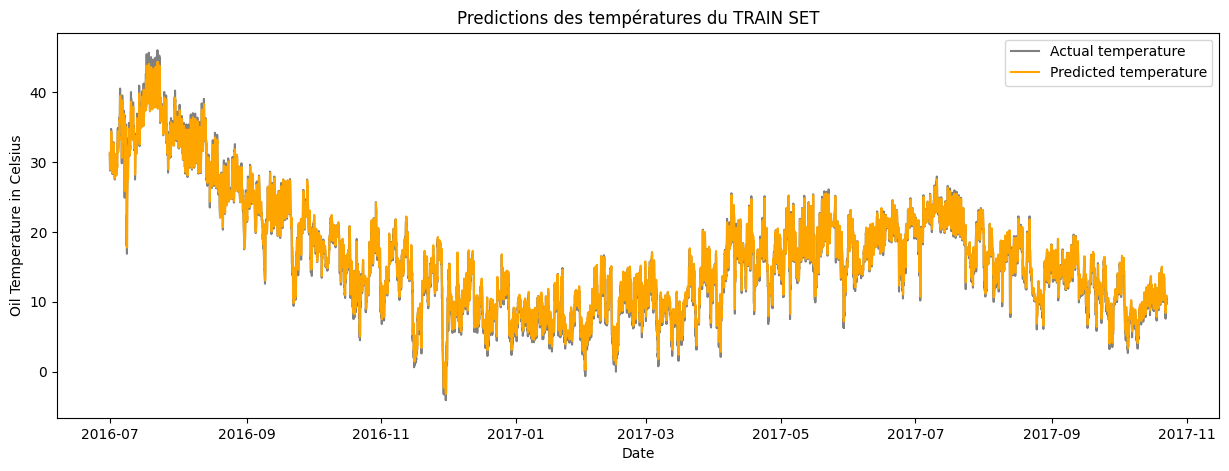

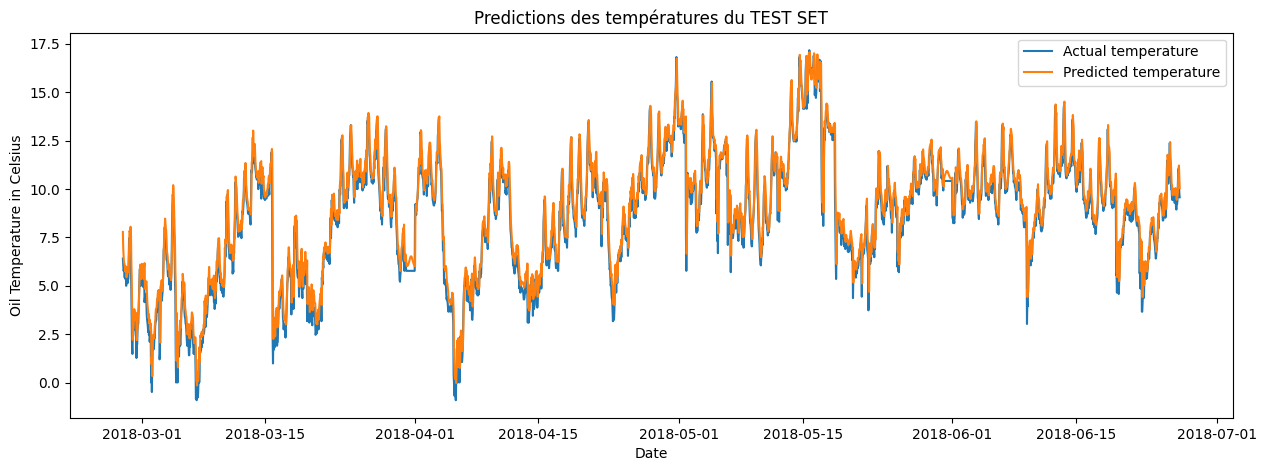

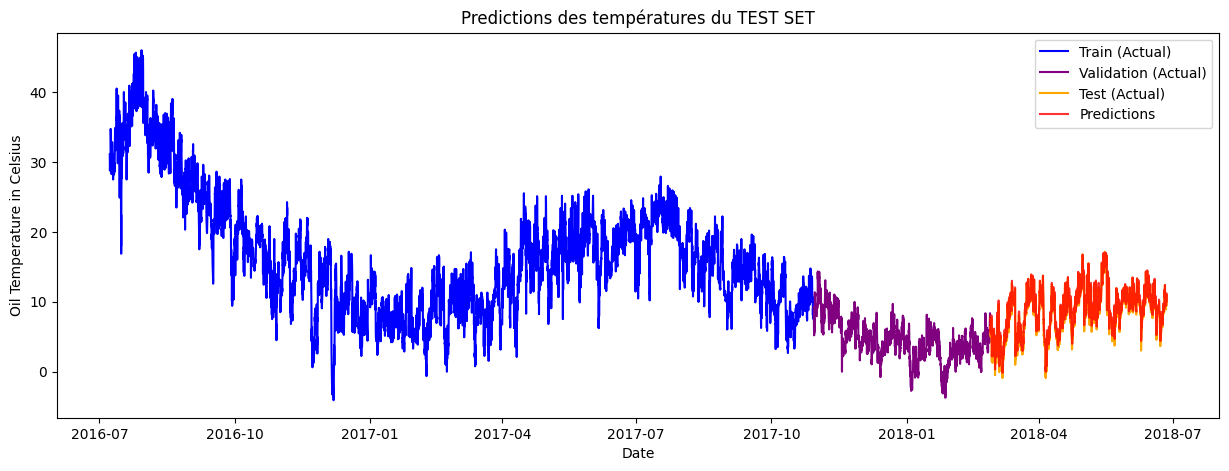

--- Performances sur 2880h ---
MAE	: 0.5368
MSE	: 0.5538
RMSE	: 0.7442
MAPE	: 6.77%


In [42]:
best_model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1, output_size=HORIZON).to(device)
best_model.load_state_dict(torch.load(logdir / 'best_model.pt'))

with torch.no_grad():
    y_pred_train = model(X_train.to(device)).detach().to('cpu').numpy()
    y_pred_test= model(X_test.to(device)).detach().to('cpu').numpy()


y_pred_train_rescaled = scaler.inverse_transform(y_pred_train)
y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1))
plt.figure(figsize = (15,5))
plt.plot(df1.index[:len(y_train_rescaled)], y_train_rescaled, color='grey', alpha=1, label="Actual temperature")
plt.plot(df1.index[:len(y_train_rescaled)], y_pred_train_rescaled, color ='orange', label="Predicted temperature")
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TRAIN SET")
plt.legend()
plt.show()



y_pred_test_rescaled = scaler.inverse_transform(y_pred_test)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
plt.figure(figsize = (15,5))
plt.plot(df1.index[-len(y_test_rescaled):], y_test_rescaled, label="Actual temperature")
plt.plot(df1.index[-len(y_test_rescaled):], y_pred_test_rescaled, label="Predicted temperature")
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TEST SET")
plt.legend()
plt.show()

y_val_rescaled = scaler.inverse_transform(y_val.reshape(-1, 1))
plt.figure(figsize = (15,5))
plt.plot(df1.index[WINDOW:len(y_train_rescaled)+WINDOW], y_train_rescaled, color='blue', alpha=1, label="Train (Actual)")
plt.plot(df1.index[-2*len(y_val_rescaled):-len(y_val_rescaled)], y_val_rescaled, color="purple", label="Validation (Actual)")
plt.plot(df1.index[-len(y_test_rescaled):], y_test_rescaled, color="orange", label="Test (Actual)")
plt.plot(df1.index[-len(y_test_rescaled):], y_pred_test_rescaled, color="red", alpha=0.8, label="Predictions")
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TEST SET")
plt.legend()
plt.show()

shift_value = np.abs(min(min(y_test_rescaled), min(y_pred_test_rescaled))) + 1
mae = mean_absolute_error(y_test_rescaled, y_pred_test_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_test_rescaled)
mape = np.mean((np.abs((y_test_rescaled+shift_value) - (y_pred_test_rescaled+shift_value))/(y_test_rescaled+shift_value))*100)

print(f"--- Performances sur {X_test.size(0)}h ---")
print(f"MAE\t: {mae:.4f}")
print(f"MSE\t: {mse:.4f}")
print(f"RMSE\t: {np.sqrt(mse):.4f}")
print(f"MAPE\t: {mape:.2f}%")

In [44]:
print(y_pred_test_rescaled)

# index temporel du dataset original
dates = univariate1.index[-len(y_pred_test_rescaled):]

# reconstruire la série
pred_series = pd.Series(y_pred_test_rescaled.flatten(), index=dates, name="prediction")
pred_series

[[ 7.778117 ]
 [ 6.9144583]
 [ 6.547737 ]
 ...
 [11.210076 ]
 [10.549136 ]
 [10.042373 ]]


date
2018-02-26 20:00:00     7.778117
2018-02-26 21:00:00     6.914458
2018-02-26 22:00:00     6.547737
2018-02-26 23:00:00     6.185725
2018-02-27 00:00:00     6.166406
                         ...    
2018-06-26 15:00:00    10.411433
2018-06-26 16:00:00    11.049862
2018-06-26 17:00:00    11.210076
2018-06-26 18:00:00    10.549136
2018-06-26 19:00:00    10.042373
Name: prediction, Length: 2880, dtype: float32

W = 24:
--- Performances sur 2880h ---
MAE	: 0.4783
MSE	: 0.4707
RMSE	: 0.6861
MAPE	: 5.48%

W= 168:
24:
--- Performances sur 2880h ---
MAE	: 0.4783
MSE	: 0.4707
RMSE	: 0.6861
MAPE	: 5.48%

## Prédictions 24h

In [ ]:
# ------------- DATA -------------
X_train, X_val, X_test, y_train, y_val, y_test = splitting(X,y,24)
print("On a bien des séquences [lag-w, ..., lag-1], ce qui est le bon sesn pour le LSTM.") if y_train[0] == X_train[1][WINDOW-1] else print("Les séquences sont à l'envers, c'est à dire [lag-1, ..., lag-w]")
train_loader, val_loader, test_loader = get_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test)

# ------------- MODEL -------------
model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1, output_size=HORIZON).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
loss  = nn.MSELoss()

# ------------- CALLBACKS -------------
logname = "LSTM24h"
logdir = generate_unique_logpath("outputs/checkpoints", logname)
setup_logging(logdir, mode="train")
logdir = pathlib.Path(logdir)
checkpoint = ModelCheckpoint(model, str(logdir / "best_model.pt"), min_is_best=True)

torch.Size([17204, 168, 1]) torch.Size([24, 168, 1]) torch.Size([24, 168, 1]) torch.Size([17204]) torch.Size([24]) torch.Size([24])
On a bien des séquences [lag-w, ..., lag-1], ce qui est le bon sesn pour le LSTM.
torch.Size([64, 168, 1]) torch.Size([64, 1])


In [197]:
# ------------- TRAINING -------------

for epoch in tqdm.tqdm(range(EPOCHS)):
    train_loss = train_one_epoch(model, train_loader, loss, optim, device)
    val_loss = validate(model, val_loader, loss, device)
    print(f"Epoch {epoch+1},\tTrain Loss : {train_loss:.5f},\tVal Loss : {val_loss:.5f}")
    
    updated = checkpoint.update(val_loss)
    if updated:
        print("New best model saved!")

  2%|▏         | 1/50 [00:01<01:01,  1.26s/it]

Epoch 1,	Train Loss : 0.02142,	Val Loss : 0.00125
New best model saved!


  4%|▍         | 2/50 [00:01<00:45,  1.05it/s]

Epoch 2,	Train Loss : 0.00316,	Val Loss : 0.00104
New best model saved!


  6%|▌         | 3/50 [00:02<00:39,  1.19it/s]

...

Epoch 48,	Train Loss : 0.00125,	Val Loss : 0.00067


 98%|█████████▊| 49/50 [00:36<00:00,  1.33it/s]

Epoch 49,	Train Loss : 0.00126,	Val Loss : 0.00052


100%|██████████| 50/50 [00:37<00:00,  1.34it/s]

Epoch 50,	Train Loss : 0.00125,	Val Loss : 0.00068


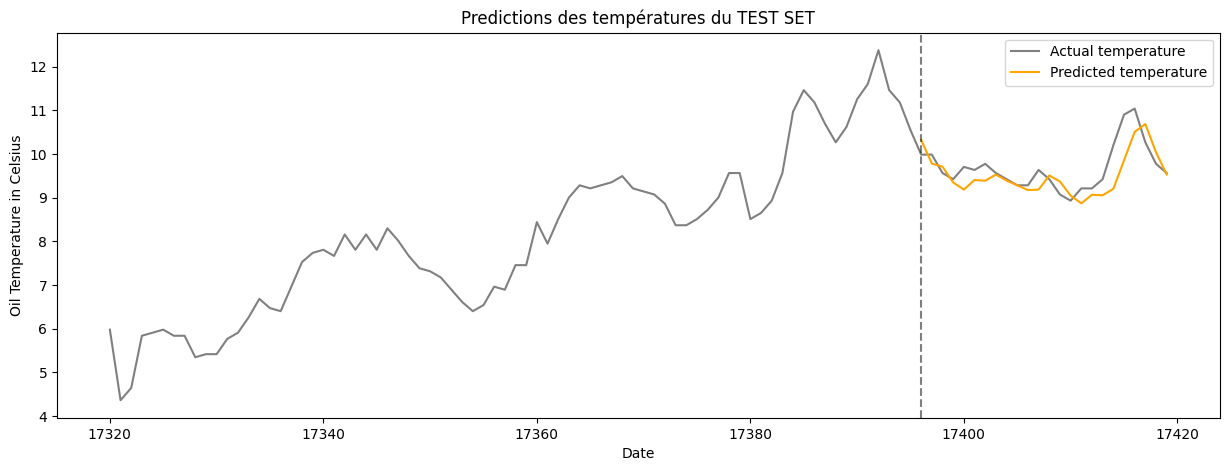

--- Performances sur 24h ---
MAE	: 0.2989
MSE	: 0.1616
RMSE	: 0.4020
MAPE	: 1.51%


In [215]:
# ------------- PREDICTIONS -------------
best_model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1).to(device)
best_model.load_state_dict(torch.load(logdir / 'best_model.pt'))

with torch.no_grad():
    y_pred_train = model(X_train.to(device)).detach().to('cpu').numpy()
    y_pred_test= model(X_test.to(device)).detach().to('cpu').numpy()


y_pred_test_rescaled = scaler.inverse_transform(y_pred_test)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
y_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

plt.figure(figsize = (15,5))
plt.plot(df1.index[-100:], y_rescaled[-100:], color="grey", label="Actual temperature")
plt.plot(df1.index[-len(y_test_rescaled):], y_pred_test_rescaled, color="orange", label="Predicted temperature")
plt.axvline(df1.index[-len(y_test_rescaled):].min(), color="black", linestyle='--', alpha=0.5)
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TEST SET")
plt.legend()
plt.show()

shift_value = np.abs(min(min(y_test_rescaled), min(y_pred_test_rescaled))) + 1
mae = mean_absolute_error(y_test_rescaled, y_pred_test_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_test_rescaled)
mape = np.mean((np.abs((y_test_rescaled+shift_value) - (y_pred_test_rescaled+shift_value))/(y_test_rescaled+shift_value))*100)

print(f"--- Performances sur {X_test.size(0)}h ---")
print(f"MAE\t: {mae:.4f}")
print(f"MSE\t: {mse:.4f}")
print(f"RMSE\t: {np.sqrt(mse):.4f}")
print(f"MAPE\t: {mape:.2f}%")

# Test SANDBOX

In [116]:
HORIZON = 24
WINDOW  = 168

In [117]:
def splitting(data, n_test):
    TRAIN = data[:-2*n_test]
    VAL   = X[-2*n_test:-n_test]
    TEST  = X[-n_test:]

    assert len(TRAIN)+len(VAL)+len(TEST) == len(data)
    print(TRAIN.shape, VAL.shape, TEST.shape)
    return TRAIN, VAL, TEST

def create_sequences(data, window, horizon, steps):
    input, output = [], []
    if isinstance(data, pd.DataFrame):
        for idx in range(0, len(data) - window - horizon + 1, steps):
            input.append(data[TARGET][idx:idx + window]) # de t à t+w
            output.append(data[TARGET].iloc[idx + window:idx + window + horizon]) # de t+w à t+w+h

    elif isinstance(data, np.ndarray):
        for idx in range(0, len(data) - window - horizon + 1, steps):
            input.append(data[idx:idx + window, 0])
            output.append(data[idx + window:idx + window + horizon, 0])
    return np.asarray(input), np.asarray(output)

In [118]:
TRAIN, VAL, TEST = splitting(scaled_data, 2880+WINDOW)

X_train, y_train = create_sequences(TRAIN, WINDOW, HORIZON, steps=1)
X_val, y_val     = create_sequences(VAL, WINDOW, HORIZON, steps=HORIZON)     # Pas de chevauchement en val
X_test, y_test   = create_sequences(TEST, WINDOW, HORIZON, steps=HORIZON)  # Pas de chevauchement en test

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

X_train = X_train.unsqueeze(-1)
y_val = y_val.squeeze(-1)
y_test = y_test.squeeze(-1)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(11324, 1) (3048, 168, 1) (3048, 168, 1)
torch.Size([11133, 168, 1]) torch.Size([11133, 24])
torch.Size([120, 168, 1]) torch.Size([120, 24])
torch.Size([120, 168, 1]) torch.Size([120, 24])


In [119]:
print("On a bien des séquences [lag-w, ..., lag-1], ce qui est le bon sesn pour le LSTM.") if y_train[0][0] == X_train[1][WINDOW-1][0] else print("Les séquences sont à l'envers, c'est à dire [lag-1, ..., lag-w]")
train_loader, val_loader, test_loader = get_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test)

On a bien des séquences [lag-w, ..., lag-1], ce qui est le bon sesn pour le LSTM.


For TRAIN : torch.Size([64, 168, 1]) torch.Size([64, 24])
For TEST : torch.Size([64, 168, 1]) torch.Size([64, 24])


In [120]:
# ------------- MODEL -------------
model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1, output_size=HORIZON).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
loss  = nn.MSELoss()

# ------------- CALLBACKS -------------
logname = "LSTM_HORIZON24_TEST2880"
logdir = generate_unique_logpath("outputs/checkpoints", logname)
setup_logging(logdir, mode="train")
logdir = pathlib.Path(logdir)
checkpoint = ModelCheckpoint(model, str(logdir / "best_model.pt"), min_is_best=True)

In [121]:
# ------------- TRAINING -------------
for epoch in tqdm.tqdm(range(EPOCHS)):
    train_loss = train_one_epoch(model, train_loader, loss, optim, device)
    val_loss = validate(model, val_loader, loss, device)
    print(f"Epoch {epoch+1},\tTrain Loss : {train_loss:.5f},\tVal Loss : {val_loss:.5f}")
    
    updated = checkpoint.update(val_loss)
    if updated:
        print("New best model saved!")

  2%|▏         | 1/50 [00:00<00:36,  1.32it/s]

Epoch 1,	Train Loss : 0.04855,	Val Loss : 0.01191
New best model saved!


  4%|▍         | 2/50 [00:01<00:27,  1.74it/s]

Epoch 2,	Train Loss : 0.01308,	Val Loss : 0.01653


  6%|▌         | 3/50 [00:01<00:24,  1.88it/s]

...

Epoch 48,	Train Loss : 0.01007,	Val Loss : 0.00845


 98%|█████████▊| 49/50 [00:23<00:00,  2.22it/s]

Epoch 49,	Train Loss : 0.01007,	Val Loss : 0.00794


100%|██████████| 50/50 [00:23<00:00,  2.13it/s]

Epoch 50,	Train Loss : 0.01016,	Val Loss : 0.00853


In [125]:
best_model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1, output_size=HORIZON).to(device)
best_model.load_state_dict(torch.load(logdir / 'best_model.pt'))

with torch.no_grad():
    y_pred_train = model(X_train.to(device)).detach().to('cpu').numpy()
    y_pred_test= model(X_test.to(device)).detach().to('cpu').numpy()

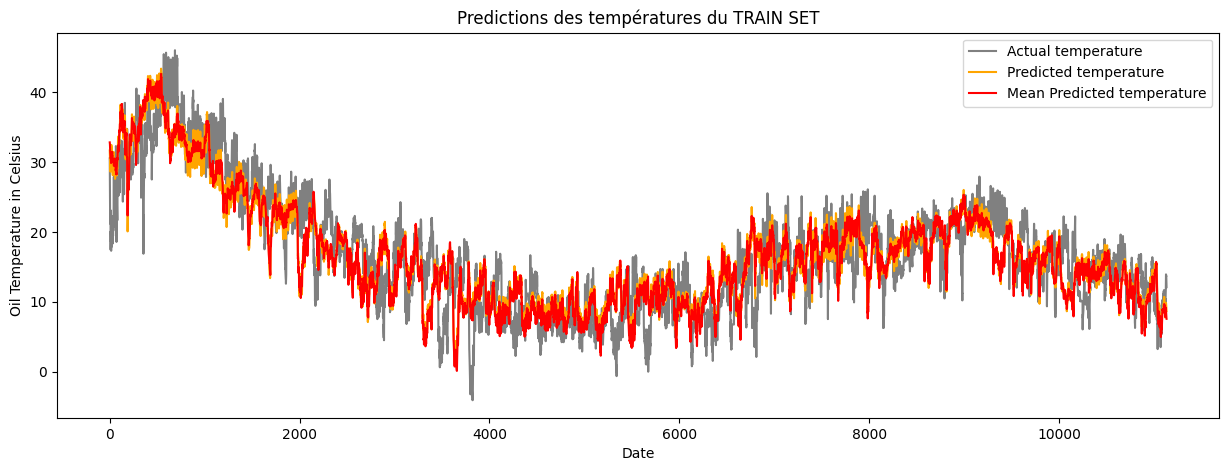

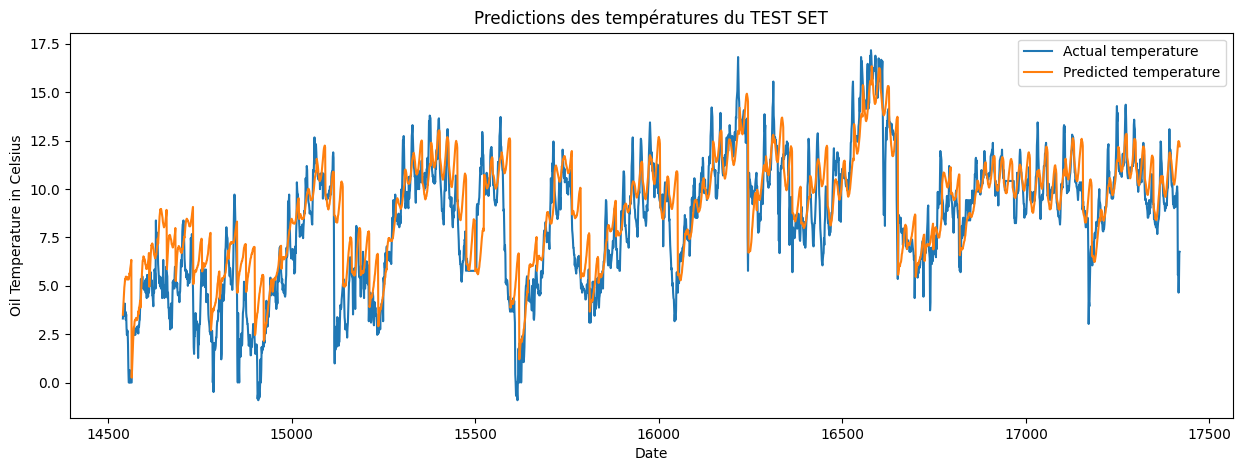

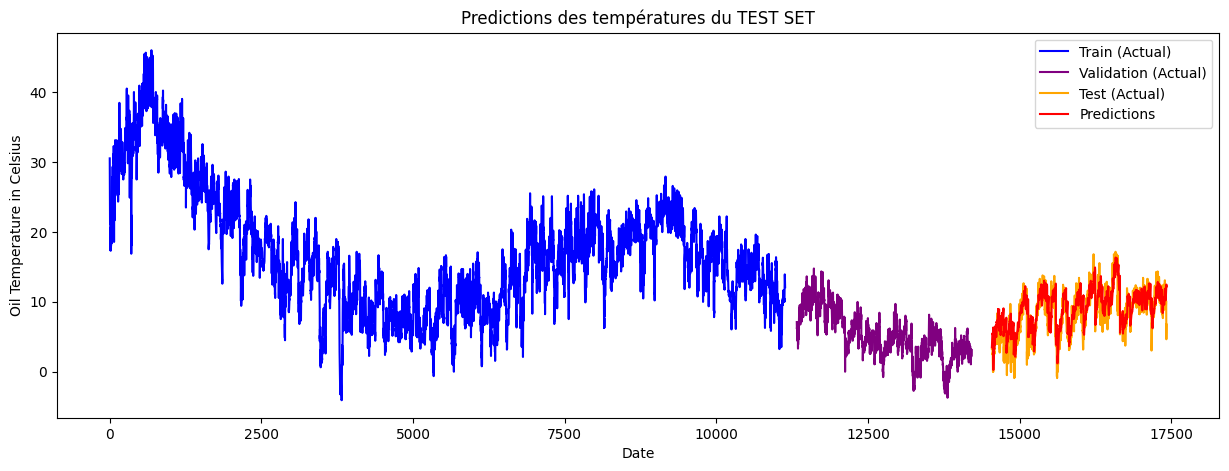

--- Performances sur 120h ---
MAE	: 1.3814
MSE	: 3.8004
RMSE	: 1.9495
MAPE	: 47.42%


In [205]:
best_model = LSTM(input_size=NB_OF_FEATURES, hidden_size=HIDDEN_SIZE_LAYER, num_stacked_layer=1, output_size=HORIZON).to(device)
best_model.load_state_dict(torch.load(logdir / 'best_model.pt'))

with torch.no_grad():
    y_pred_train = model(X_train.to(device)).detach().to('cpu').numpy()
    y_pred_test= model(X_test.to(device)).detach().to('cpu').numpy()


y_pred_train_rescaled = scaler.inverse_transform(y_pred_train)
y_train_rescaled = scaler.inverse_transform(TRAIN[:-(WINDOW+HORIZON-1)].reshape(-1, 1))
plt.figure(figsize = (15,5))
plt.plot(df1.index[:(len(TRAIN)-WINDOW-HORIZON+1)], y_train_rescaled, color='grey', alpha=1, label="Actual temperature")
plt.plot(df1.index[:(len(TRAIN)-WINDOW-HORIZON+1)], y_pred_train_rescaled[:,23], color ='orange', label="Predicted temperature")
plt.plot(df1.index[:(len(TRAIN)-WINDOW-HORIZON+1)], np.mean(y_pred_train_rescaled ,axis=1), color ='red', label="Mean Predicted temperature")
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TRAIN SET")
plt.legend()
plt.show()



y_pred_test_rescaled = scaler.inverse_transform(y_pred_test).flatten()
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
plt.figure(figsize = (15,5))
plt.plot(df1.index[-(len(TEST)-WINDOW):], y_test_rescaled, label="Actual temperature")
plt.plot(df1.index[-(len(TEST)-WINDOW):], y_pred_test_rescaled, label="Predicted temperature")
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TEST SET")
plt.legend()
plt.show()

y_val_rescaled = scaler.inverse_transform(y_val.reshape(-1, 1))
plt.figure(figsize = (15,5))
plt.plot(df1.index[:(len(TRAIN)-WINDOW-HORIZON+1)], y_train_rescaled, color='blue', alpha=1, label="Train (Actual)")
plt.plot(df1.index[-((2*len(VAL))):-len(VAL)-WINDOW], y_val_rescaled, color="purple", label="Validation (Actual)")
plt.plot(df1.index[-(len(TEST)-WINDOW):], y_test_rescaled, color="orange", label="Test (Actual)")
plt.plot(df1.index[-(len(TEST)-WINDOW):], y_pred_test_rescaled, color="red", label="Predictions")
plt.xlabel('Date')
plt.ylabel("Oil Temperature in Celsius")
plt.title("Predictions des températures du TEST SET")
plt.legend()
plt.show()

shift_value = np.abs(min(min(y_test_rescaled), min(y_pred_test_rescaled))) + 1
mae = mean_absolute_error(y_test_rescaled, y_pred_test_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_test_rescaled)
mape = np.mean((np.abs((y_test_rescaled+shift_value) - (y_pred_test_rescaled+shift_value))/(y_test_rescaled+shift_value))*100)

print(f"--- Performances sur {X_test.size(0)}h ---")
print(f"MAE\t: {mae:.4f}")
print(f"MSE\t: {mse:.4f}")
print(f"RMSE\t: {np.sqrt(mse):.4f}")
print(f"MAPE\t: {mape:.2f}%")